In [33]:
import pandas as pd
from sklearn.cluster import KMeans

value_system_df = pd.read_csv('value_systems/GB_value_system.csv', sep=',', na_values=[''], quotechar='"')
value_system_df

,country,P__Universalism__Universalism,P__Universalism__Benevolence,P__Universalism__Tradition,P__Universalism__Conformity,P__Universalism__Security,P__Universalism__Power,P__Universalism__Achievement,P__Universalism__Hedonism,P__Universalism__Stimulation,...,VA__Hedonism__lgbt_adopt,VA__Hedonism__lgbt_freedom,VA__Stimulation__brexit,VA__Stimulation__immigration,VA__Stimulation__lgbt_adopt,VA__Stimulation__lgbt_freedom,VA__Self-Direction__brexit,VA__Self-Direction__immigration,VA__Self-Direction__lgbt_adopt,VA__Self-Direction__lgbt_freedom
0,21,0.5,0.555556,0.805556,0.722222,0.472222,0.888889,0.722222,0.722222,0.972222,...,0.067901,0.067901,0.623457,-0.623457,0.623457,0.623457,-3.024691e-01,3.024691e-01,-3.024691e-01,-3.024691e-01
1,23,0.5,0.583333,0.500000,0.833333,0.500000,0.916667,0.583333,0.666667,1.000000,...,-0.074074,-0.074074,0.666667,-0.666667,0.666667,0.666667,4.814815e-01,-4.814815e-01,4.814815e-01,4.814815e-01
2,53,0.5,0.375000,0.500000,0.375000,0.375000,0.875000,0.500000,0.750000,0.875000,...,0.333333,0.333333,0.611111,-0.611111,0.611111,0.611111,6.111111e-01,-6.111111e-01,6.111111e-01,6.111111e-01
3,82,0.5,0.500000,0.500000,0.583333,0.750000,1.000000,0.916667,1.000000,1.000000,...,0.277778,0.277778,-0.555556,-0.493827,0.277778,0.277778,-2.467162e-17,-2.193033e-17,1.233581e-17,1.233581e-17
4,89,0.5,0.500000,0.300000,0.600000,0.600000,0.700000,0.600000,0.200000,0.400000,...,-0.300000,-0.300000,0.155556,0.155556,-0.077778,-0.077778,3.777778e-01,3.777778e-01,-1.888889e-01,-1.888889e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1941,69664,0.5,0.437500,0.812500,0.875000,0.625000,0.687500,0.625000,0.625000,0.500000,...,0.041667,0.041667,-0.236111,0.236111,-0.236111,-0.236111,-5.138889e-01,5.138889e-01,-5.138889e-01,-5.138889e-01
1942,69820,0.5,0.428571,0.285714,0.285714,0.285714,0.785714,0.785714,0.357143,0.714286,...,-0.134921,-0.134921,0.523810,-0.232804,0.261905,0.261905,-2.698413e-01,1.199295e-01,-1.349206e-01,-1.349206e-01
1943,69885,0.5,0.444444,0.611111,0.777778,0.777778,0.944444,0.944444,0.694444,0.777778,...,-0.015432,-0.030864,-0.154321,-0.154321,0.077160,0.154321,2.160494e-01,2.160494e-01,-1.080247e-01,-2.160494e-01
1944,69887,0.5,0.523810,0.952381,0.595238,0.452381,0.738095,0.595238,0.523810,0.880952,...,0.000000,-0.140212,0.513228,-0.513228,-0.000000,0.256614,1.957672e-01,-1.957672e-01,-0.000000e+00,9.788360e-02


## Notes

- "Immigration" means "Immigration bad or good for country's economy", where a higher value means **good**.
- "lgbt_freedom" means "Gay men and lesbians should be free to live life as they wish", where a higher value means **yes**
- "lgbt_adopt" means "Gay men and lesbians should have the same rights to adopt children as straight couples", where a higher value means **yes**

- If no country is specified, plots are over **all** countries

## Step 1: Understand the relationship of action judgements
- An action judgement states: If the action is taken, then to what extent will my value be promoted or demoted? (In the opinion of the agent)

### Key Conclusions
- Polarising actions have very strong, differing promotion and demotion between agents. We can see that Immigration is the most polarising action.

- Over all agents, "Immigration" shows a medium-strength correlation between certain values and actions. There are more extreme views portrayed, showing an increased level of polarisation.
- For LGBT rights and adoption, there is no strong correlation between actions and values. There is no overall trend, and the actions are not very polarising.

In [34]:
# Find all columns that start with "P__"
pref_cols = pd.DataFrame(value_system_df.filter(regex="^P__"))
# Remove all cols that have the same two values (P__Universalism__Universalism, P__Benevolence__Benevolence, etc.)
for col in pref_cols.columns:
    col_split = col.split("__")
    if len(col_split) == 3 and col_split[1] == col_split[2]:
        pref_cols = pref_cols.drop(col, axis=1)
    else:
        # Not dropped, so drop the symmetrical col (P__A__B == P__B__A)
        symmetrical_col = "P__"+ col_split[2] + "__" + col_split[1]
        if col in pref_cols.columns:
            pref_cols = pref_cols.drop(columns=[symmetrical_col], axis=1)

In [35]:
stds = pref_cols.std()
stds = stds.sort_values(ascending=True)
print("Standard Deviations for each comparison: \n", stds)

Standard Deviations for each comparison: 
 P__Universalism__Benevolence       0.137675
P__Benevolence__Power              0.158972
P__Benevolence__Tradition          0.164403
P__Benevolence__Security           0.166328
P__Universalism__Self-Direction    0.168083
P__Benevolence__Self-Direction     0.170566
P__Universalism__Tradition         0.174211
P__Power__Achievement              0.176924
P__Universalism__Power             0.178432
P__Power__Self-Direction           0.179141
P__Universalism__Security          0.182053
P__Benevolence__Hedonism           0.183370
P__Benevolence__Achievement        0.184185
P__Benevolence__Conformity         0.185110
P__Security__Power                 0.185841
P__Tradition__Security             0.188662
P__Conformity__Security            0.189631
P__Stimulation__Self-Direction     0.190082
P__Tradition__Conformity           0.191354
P__Hedonism__Stimulation           0.191624
P__Benevolence__Stimulation        0.192222
P__Universalism__Conformity      

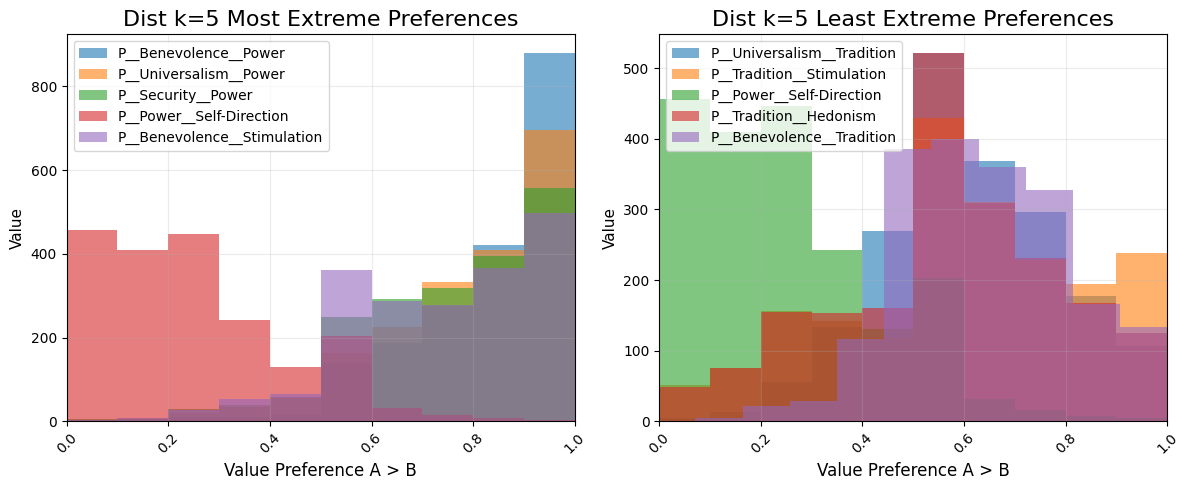

In [36]:
# There are 45 pairwise comparisons, look at top 10 for each (most nothing, most strong)
import matplotlib.pyplot as plt
k = 5
# Find cols that have a mean closest to 0 or 1, find the absolute difference to either 0 or 1 (depending on which side of 0.5 they're on), and then rank the distances
high_means = pref_cols.mean(axis=0).sort_values(ascending=False)
low_means = pref_cols.mean(axis=0).sort_values(ascending=True)
# Clip values
high_means = high_means.clip(lower=0.5, upper=1.0)
low_means = low_means.clip(lower=0.0, upper=0.5)
# Find diff
high_means = 1 - high_means
# Concat
means = pd.concat([high_means, low_means])
means = means.sort_values(ascending=True)

means_keys_high = means.keys().tolist()[:k]
#print("High keys: ", means_keys_high)
means = means.sort_values(ascending=False)
means_keys_low = means.keys().tolist()[:k]
#print("Low keys: ", means_keys_low)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1]})

for col in means_keys_high:
    pref_cols.hist(col, bins=10, alpha=0.6, label=col, ax=axes[0])
axes[0].set_title(f"Dist k={k} Most Extreme Preferences", fontsize=16)
axes[0].set_xlabel('Value Preference A > B', fontsize=12)
axes[0].set_ylabel('Frequency Amongst Agents', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_ylabel("Value", fontsize=11)
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(alpha=0.25)
axes[0].set_xlim(0, 1)

for col in means_keys_low:
    pref_cols.hist(col, bins=10, alpha=0.6, label=col, ax=axes[1])
axes[1].set_title(f"Dist k={k} Least Extreme Preferences", fontsize=16)
axes[1].set_xlabel('Value Preference A > B', fontsize=12)
axes[1].set_ylabel('Frequency Amongst Agents', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].set_ylabel("Value", fontsize=11)
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(alpha=0.25)
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()


### Notes on Value Preferences
- What happens to the performance of value aggregators when we remove the "noise" of indifferent value preferences?
- Are the extreme value preferences reflected in our actions? Are more extreme opinions on the actions shared by agents with more extreme value preferences?

**Values in Extreme Preferences suggest:**
- *Strong preference for:* **Power**, Stimulation, Achievement
- *Strong Preference against:* Tradition, Self-Direction, Benevolence, Security, Stimulation, **Power**

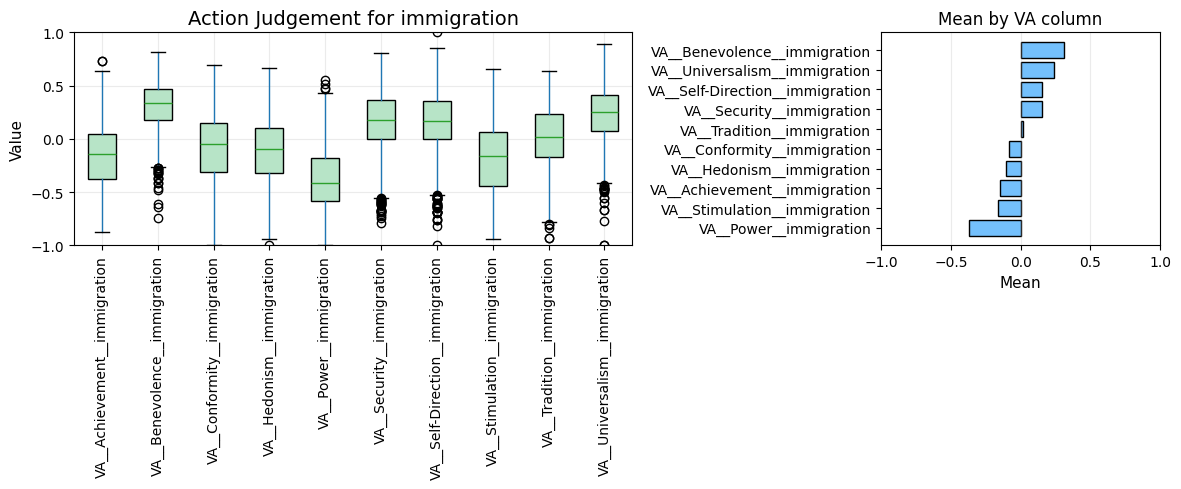

In [37]:
import re
import matplotlib.pyplot as plt

def _va_cols_for_topic(df, topic: str):
    # Get all VA columns for a given topic
    pattern = re.compile(rf"^VA__.*__{re.escape(topic)}$", flags=re.IGNORECASE)
    return [c for c in df.columns if pattern.match(c)]

def plot_va_topic(df, topic: str, figsize=(12, 5)):
    # Plot VA boxplot and mean by VA column for a given topic
    cols = _va_cols_for_topic(df, topic)
    if not cols:
        raise ValueError(f"No VA columns found for topic '{topic}'. Expected columns like 'VA__<Value>__{topic}'.")
    cols = sorted(cols)

    fig, axes = plt.subplots(1, 2, figsize=figsize, gridspec_kw={"width_ratios": [2, 1]})

    df[cols].boxplot(ax=axes[0], patch_artist=True, boxprops=dict(facecolor="#b7e4c7"))
    axes[0].set_title(f"Action Judgement for {topic}", fontsize=14)
    axes[0].set_ylabel("Value", fontsize=11)
    axes[0].tick_params(axis="x", rotation=90)
    axes[0].set_ylim(-1, 1)
    axes[0].grid(alpha=0.25)

    means = df[cols].mean(numeric_only=True).sort_values(ascending=False)
    axes[1].barh(means.index, means.values, color="#74c0fc", edgecolor="black")
    axes[1].set_title("Mean by VA column", fontsize=12)
    axes[1].set_xlabel("Mean", fontsize=11)
    axes[1].invert_yaxis()
    axes[1].set_xlim(-1, 1)
    axes[1].grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()

plot_va_topic(value_system_df, "immigration")

### Notes: Immigration is good for the economony Action
- Medium-Strength (+/- 0.5) matching Schwartz Values
    - Self-Direction, Stimulation, Power, Benevolence, Universalism

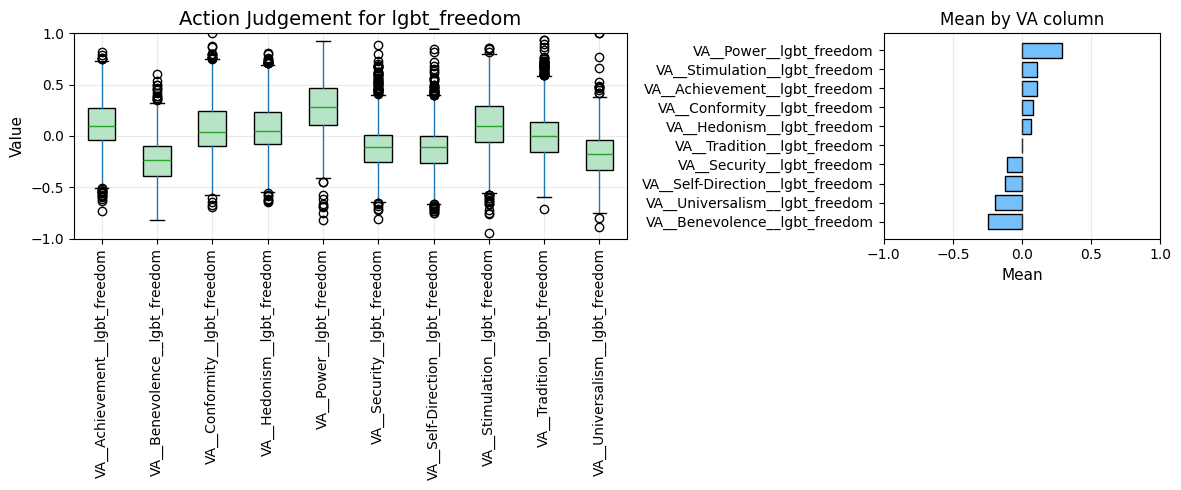

In [38]:
plot_va_topic(value_system_df, "lgbt_freedom")

### Notes: LGBT Rights Action
- Low-Strength correlation between values and actions, with a few agents having stronger correlations.
- No overall large trend.

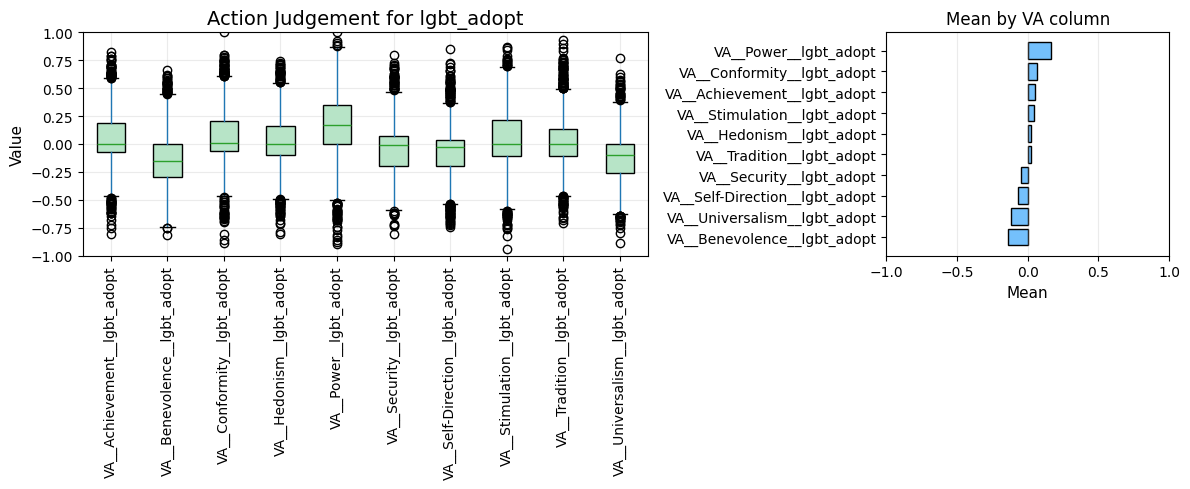

In [39]:
plot_va_topic(value_system_df, "lgbt_adopt")


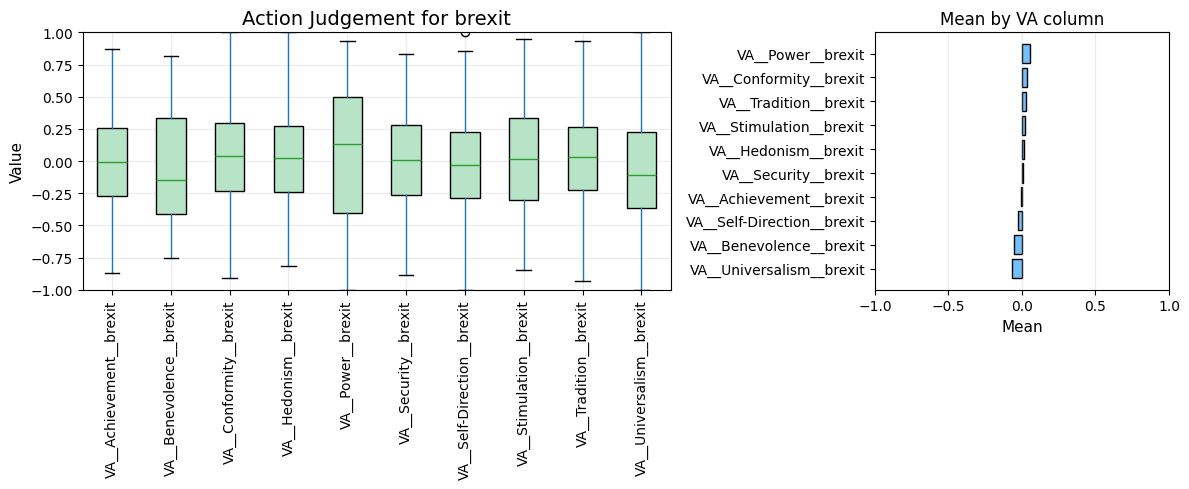

In [40]:
plot_va_topic(value_system_df, "brexit")

### Notes: LGBT Adoption Action
- Low-Strength correlation with no extreme positions within the entire group.

### K-Means clustering/PCA analysis to find clusters of agents with similar action judgements
- Here we are looking to find distinct clusters. An ideal scenario would be i) one large cluster, with a small opposing cluster ii) two strongly opposing clusters of similar size. iii) No clear clusters.

PCA for brexit: ['VA__Achievement__brexit', 'VA__Benevolence__brexit', 'VA__Conformity__brexit', 'VA__Hedonism__brexit', 'VA__Power__brexit', 'VA__Security__brexit', 'VA__Self-Direction__brexit', 'VA__Stimulation__brexit', 'VA__Tradition__brexit', 'VA__Universalism__brexit']
(1946, 10)
(1946, 10)
(1946, 2)
PCA for immigration: ['VA__Achievement__immigration', 'VA__Benevolence__immigration', 'VA__Conformity__immigration', 'VA__Hedonism__immigration', 'VA__Power__immigration', 'VA__Security__immigration', 'VA__Self-Direction__immigration', 'VA__Stimulation__immigration', 'VA__Tradition__immigration', 'VA__Universalism__immigration']
(1946, 10)
(1946, 10)
(1946, 2)
PCA for lgbt_adopt: ['VA__Achievement__lgbt_adopt', 'VA__Benevolence__lgbt_adopt', 'VA__Conformity__lgbt_adopt', 'VA__Hedonism__lgbt_adopt', 'VA__Power__lgbt_adopt', 'VA__Security__lgbt_adopt', 'VA__Self-Direction__lgbt_adopt', 'VA__Stimulation__lgbt_adopt', 'VA__Tradition__lgbt_adopt', 'VA__Universalism__lgbt_adopt']
(1946, 10

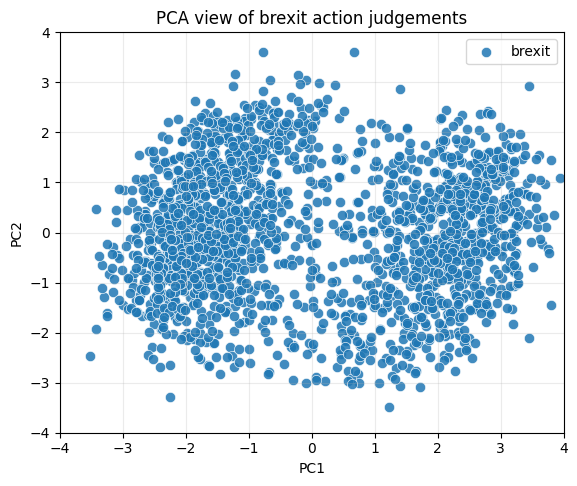

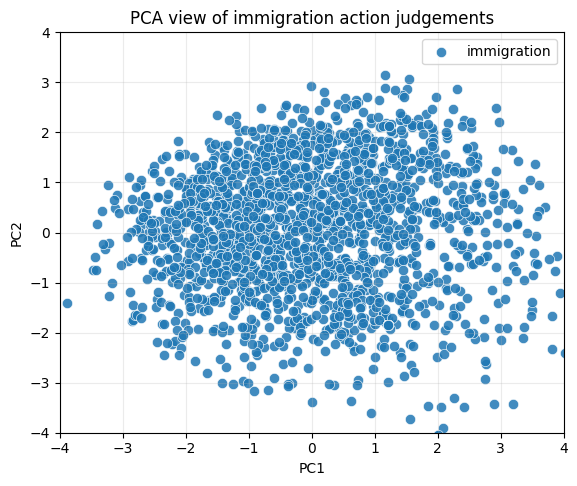

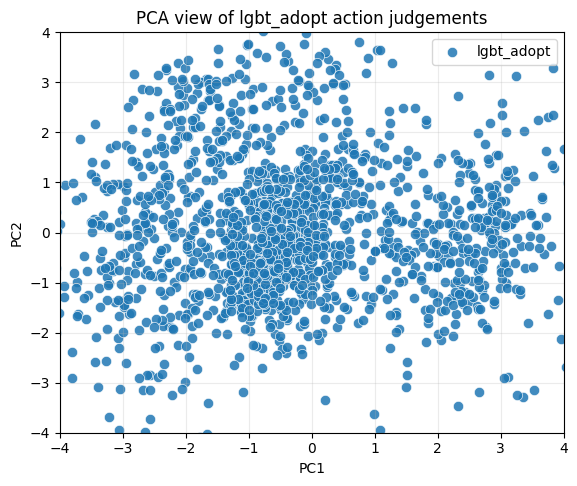

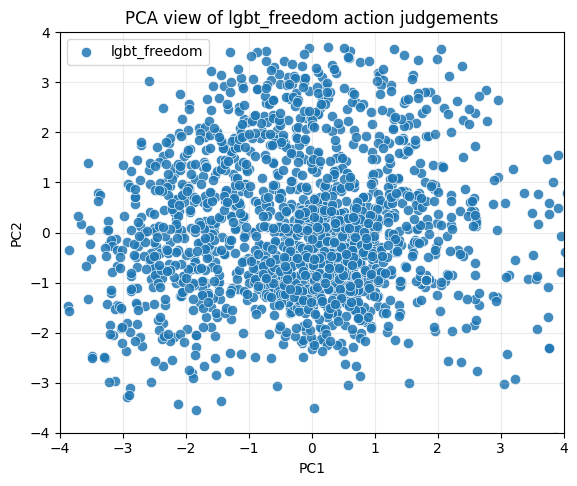

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _va_cols_for_action(df: pd.DataFrame, action: str):
    suffix = f"__{action}"
    return [c for c in df.columns if c.startswith("VA__") and c.endswith(suffix)]

def PCA_per_action(df, actions=("brexit", "immigration", "lgbt_adopt", "lgbt_freedom")):
    for action in actions:
        cols = sorted(_va_cols_for_action(df, action))
        print(f"PCA for {action}: {cols}")
        scaler = StandardScaler()
        # take col value_systems, and scale between 0-1, std 1, for PCA
        X = df[cols].to_numpy(dtype=float)
        print(X.shape)
        X = scaler.fit_transform(X)
        print(X.shape)
        pca_output = PCA(n_components=2).fit_transform(X)
        print(pca_output.shape)

        plt.figure(figsize=(6.5, 5.2))
        plt.scatter(pca_output[:, 0], pca_output[:, 1], s=55, alpha=0.85, edgecolor="white", linewidth=0.5, label=action)
        plt.title(f"PCA view of {action} action judgements")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.xlim(-4, 4)
        plt.ylim(-4, 4)
        plt.grid(alpha=0.25)
        plt.legend(frameon=True)

PCA_per_action(value_system_df)

In [42]:
## K Means Clustering per action
import seaborn as sns

def k_means_actions(df, actions=("immigration", "lgbt_adopt", "lgbt_freedom")):
    for action in actions:
        cols = _va_cols_for_action(df, action)
        X = df[cols].to_numpy(dtype=float)
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
        kmeans = KMeans(n_clusters=2, random_state=0).fit_predict(X)
        ## Have two plots, one showing the clusters, another showing the decisions made by each cluster
        ## Decision is calculated as the sum of each value judgement multiplied by the associated preference for a value

        plt.figure(figsize=(6.5, 5.2))
        plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap="tab10", s=55, alpha=0.85, edgecolor="white", linewidth=0.5, label=action)
        plt.title(f"K-Means clustering of {action} action judgements")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.xlim(-4,4)
        plt.ylim(-4, 4)


        sns.boxplot(x= means.labels_)

k_means_actions(value_system_df)


AttributeError: 'numpy.ndarray' object has no attribute 'labels_'

<Figure size 650x520 with 0 Axes>

### Step 3: Connection between principles and personal values

### Step 4: Correlation with real support/disagreement and decision made by an agent's PVS